# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import f1_score, classification_report

# Загрузка и очистка данных

In [2]:
# Загрузка данных
df = pd.read_csv('agriculture.csv', sep=';', encoding='cp1251')

# Очистка названий столбцов
df.columns = df.columns.str.strip()

# Приведение строковых значений к единому виду
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Удаление лишнего суффикса
df['Наименование вида сельхоз. продукции'] = (
    df['Наименование вида сельхоз. продукции']
    .str.replace(', тыс. штук', '', regex=False)
)

# Функция преобразования строк в числа
def convert_to_float(series):
    series = series.astype(str).str.replace(',', '.', regex=False).str.strip()
    return pd.to_numeric(series, errors='coerce')

# Преобразование числовых столбцов
df['Показатель, тыс. ед.'] = convert_to_float(df['Показатель, тыс. ед.'])
df['Доля'] = convert_to_float(df['Доля'])
df['Темп роста, %'] = convert_to_float(df['Темп роста, %'])
df['Год'] = pd.to_numeric(df['Год'], errors='coerce')

print(df.head())
print(df.isna().sum())

            Сектор Наименование вида сельхоз. продукции   Год  \
0  растениеводство                   капуста всех видов  1999   
1  растениеводство                   капуста всех видов  2000   
2  растениеводство                   капуста всех видов  2001   
3  растениеводство                   капуста всех видов  2002   
4  растениеводство                   капуста всех видов  2003   

   Показатель, тыс. ед.      Доля  Темп роста, % Категория  
0                166.18  0.002884            NaN   высокий  
1                156.63  0.002820      -5.746781   высокий  
2                146.04  0.002609      -6.761157   высокий  
3                140.55  0.002487      -3.759244   высокий  
4                137.69  0.002613      -2.034863   высокий  
Сектор                                   0
Наименование вида сельхоз. продукции     0
Год                                      0
Показатель, тыс. ед.                     0
Доля                                     0
Темп роста, %               

# Формирование целевой переменной

In [3]:
target_map = {'низкий': 0, 'средний': 1, 'высокий': 2}
df['Категория_ord'] = df['Категория'].map(target_map)

X = df.drop(columns=['Категория', 'Категория_ord'])
y = df['Категория_ord']

print("Размер X:", X.shape)
print("Распределение классов:")
print(y.value_counts())

Размер X: (1118, 6)
Распределение классов:
Категория_ord
2    387
0    387
1    344
Name: count, dtype: int64


# Разделение на обучающую и тестовую выборки

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (894, 6)
Тестовая выборка: (224, 6)


# Подготовка признаков

In [5]:
numeric_features = ['Год', 'Показатель, тыс. ед.', 'Доля', 'Темп роста, %']
categorical_features = ['Сектор', 'Наименование вида сельхоз. продукции']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Модель стекинга

In [6]:
stacking_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=2000, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=150, random_state=42)),
            ('knn', KNeighborsClassifier(n_neighbors=5))
        ],
        final_estimator=LogisticRegression(max_iter=2000, random_state=42),
        cv=5,
        n_jobs=-1
    ))
])

# Модель многослойного персептрона

In [7]:
mlp_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    ))
])

# Обучение моделей

In [8]:
stacking_model.fit(X_train, y_train)
mlp_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Год',
                                                   'Показатель, тыс. ед.',
                                                   'Доля', 'Темп роста, %']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Сектор',
                                                   'Наименование вида сельхоз. '
                                                   'продукции'])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000,
                               random_state=42))])

# Оценка качества

In [9]:
y_pred_stacking = stacking_model.predict(X_test)
y_pred_mlp = mlp_model.predict(X_test)

results = pd.DataFrame({
    'Модель': ['Stacking', 'MLP'],
    'F1-macro': [
        f1_score(y_test, y_pred_stacking, average='macro'),
        f1_score(y_test, y_pred_mlp, average='macro')
    ]
})

results = results.sort_values(by='F1-macro', ascending=False).reset_index(drop=True)
print(results)

     Модель  F1-macro
0  Stacking  0.795472
1       MLP  0.767259


# Подробные результаты

In [10]:
print("Stacking")
print(classification_report(y_test, y_pred_stacking))

print("MLP")
print(classification_report(y_test, y_pred_mlp))

Stacking
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        78
           1       0.69      0.70      0.69        69
           2       0.85      0.86      0.85        77

    accuracy                           0.80       224
   macro avg       0.80      0.80      0.80       224
weighted avg       0.80      0.80      0.80       224

MLP
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        78
           1       0.65      0.64      0.64        69
           2       0.80      0.83      0.82        77

    accuracy                           0.77       224
   macro avg       0.77      0.77      0.77       224
weighted avg       0.77      0.77      0.77       224



# График сравнения моделей

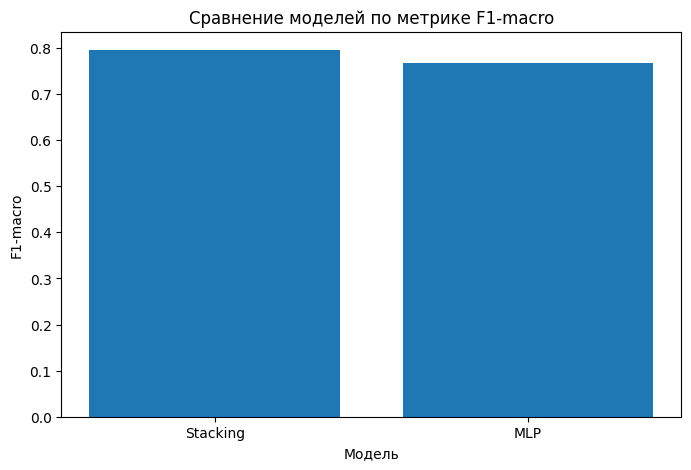

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(results['Модель'], results['F1-macro'])
plt.title('Сравнение моделей по метрике F1-macro')
plt.xlabel('Модель')
plt.ylabel('F1-macro')
plt.show()

# Выводы
Вывод:
В лабораторной работе были обучены и сравнены две модели: стекинг и многослойный персептрон. Перед обучением выполнена предварительная обработка данных: заполнение пропусков, кодирование категориальных признаков и масштабирование числовых признаков. Качество моделей оценивалось по метрике F1-macro. По результатам сравнения была определена модель, показавшая лучшее качество классификации на тестовой выборке.